In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn import preprocessing

df = pd.read_csv('../dataset/clean/stats_by_player.csv')
win_minutes_relation = pd.read_csv('../dataset/clean/win_minutes_relation.csv')

df = df.merge(win_minutes_relation.drop(columns = 'minutes'), on = 'personName')
df.columns

Index(['personName', 'teamName', 'season_year', 'position', 'minutes',
       'fieldGoalsMade', 'fieldGoalsAttempted', 'fieldGoalsPercentage',
       'threePointersMade', 'threePointersAttempted',
       'threePointersPercentage', 'freeThrowsMade', 'freeThrowsAttempted',
       'freeThrowsPercentage', 'reboundsOffensive', 'reboundsDefensive',
       'reboundsTotal', 'assists', 'steals', 'blocks', 'turnovers',
       'foulsPersonal', 'points', 'plusMinusPoints', 'W'],
      dtype='object')

In [51]:
df_c = df[df['position'].str.count('C') > 0]
df_g = df[df['position'].str.count('G') > 0]
df_f = df[df['position'].str.count('F') > 0]

c_features = ['freeThrowsMade', 'reboundsDefensive', 'reboundsOffensive', 'blocks', 'plusMinusPoints']

g_features = ['threePointersAttempted', 'assists', 'steals', 'turnovers', 'plusMinusPoints']

f_features = ['threePointersAttempted', 'reboundsDefensive', 'steals', 'turnovers', 'plusMinusPoints']

min_max_scaler = preprocessing.MinMaxScaler()
scaled = min_max_scaler.fit_transform(df_c[c_features].values)

min_max_scaler2 = preprocessing.MinMaxScaler()
scaled2 = min_max_scaler.fit_transform(df_g[g_features].values)

min_max_scaler3 = preprocessing.MinMaxScaler()
scaled3 = min_max_scaler.fit_transform(df_f[f_features].values)

df_c[c_features] = scaled
df_c = df_c[c_features + ['W','minutes']]

'''

df_c[c_features] = scaled
df_c_no_wins = df_c[c_features]
df_c = df_c[c_features + ['W']]

df_g[g_features] = scaled2
df_g_no_wins = df_g[g_features]
df_g = df_g[g_features + ['W']]

df_f[f_features] = scaled3
df_f_no_wins = df_f[g_features]
df_f = df_f[f_features + ['W']]
'''

C:\Users\Raposo\AppData\Local\Temp\ipykernel_10340\2276440697.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_c[c_features] = scaled


"\n\ndf_c[c_features] = scaled\ndf_c_no_wins = df_c[c_features]\ndf_c = df_c[c_features + ['W']]\n\ndf_g[g_features] = scaled2\ndf_g_no_wins = df_g[g_features]\ndf_g = df_g[g_features + ['W']]\n\ndf_f[f_features] = scaled3\ndf_f_no_wins = df_f[g_features]\ndf_f = df_f[f_features + ['W']]\n"

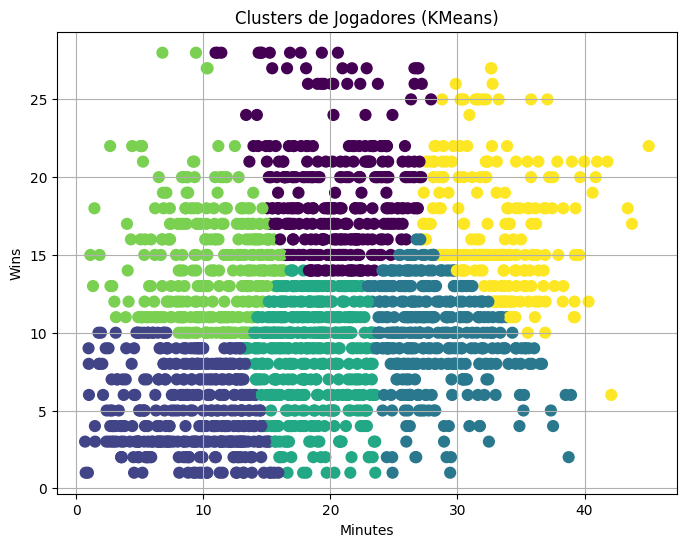

In [57]:
df_c_tmp_wins = df_c[['minutes', 'W']]

kmeans = KMeans(n_clusters=6, random_state=0, n_init="auto").fit_predict(df_c_tmp_wins)

df_c['cluster'] = kmeans

plt.figure(figsize=(8, 6))
plt.scatter(df_c['minutes'], df_c['W'], c=df_c['cluster'], cmap='viridis', s=60)
plt.xlabel('Minutes')
plt.ylabel('Wins')
plt.title('Clusters de Jogadores (KMeans)')
plt.grid(True)
plt.show()

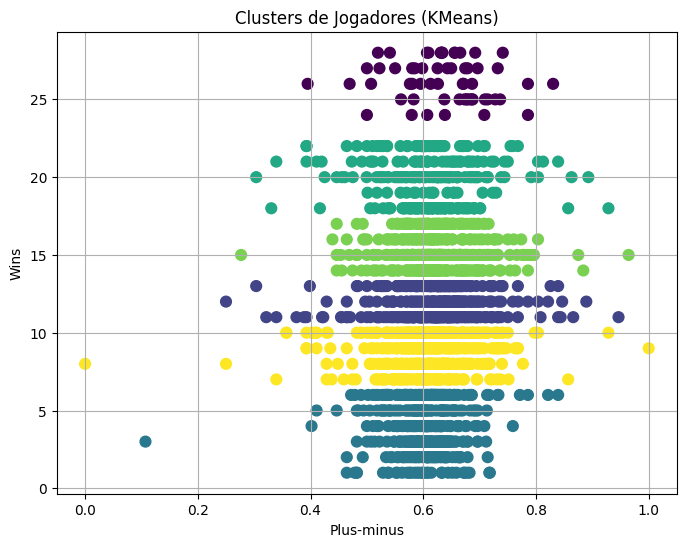

In [58]:
df_c_pm_wins = df_c[['plusMinusPoints', 'W']]

kmeans = KMeans(n_clusters=6, random_state=0, n_init="auto").fit_predict(df_c_pm_wins)

df_c['cluster'] = kmeans

plt.figure(figsize=(8, 6))
plt.scatter(df_c['plusMinusPoints'], df_c['W'], c=df_c['cluster'], cmap='viridis', s=60)
plt.xlabel('Plus-minus')
plt.ylabel('Wins')
plt.title('Clusters de Jogadores (KMeans)')
plt.grid(True)
plt.show()

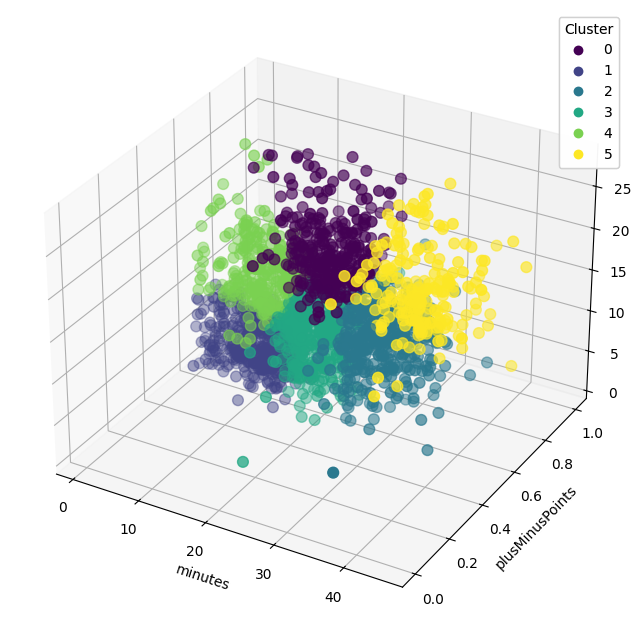

In [59]:
df_c_pm_minute_wins = df_c[['minutes', 'plusMinusPoints', 'W']]

kmeans = KMeans(n_clusters=6, random_state=0, n_init="auto").fit_predict(df_c_pm_minute_wins)

df_c['cluster'] = kmeans

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Substitua pelos nomes das suas colunas
x = df_c['minutes']
y = df_c['plusMinusPoints']
z = df_c['W']
labels = df_c['cluster']  # Clusters gerados pelo KMeans

# Plot com cores diferentes por cluster
scatter = ax.scatter(x, y, z, c=labels, cmap='viridis', s=60)

# Rótulos dos eixos
ax.set_xlabel('minutes')
ax.set_ylabel('plusMinusPoints')
ax.set_zlabel('W')

# Legenda de cores
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)

plt.show()

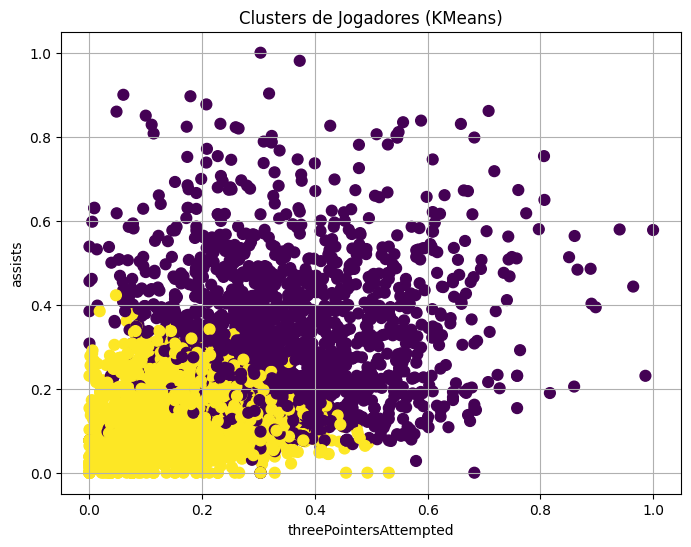

In [6]:
kmeans2 = KMeans(n_clusters=2, random_state=0, n_init="auto").fit_predict(df_g_no_wins)
df_g['cluster'] = kmeans2
plt.figure(figsize=(8, 6))
plt.scatter(df_g['threePointersAttempted'], df_g['assists'], c=df_g['cluster'], cmap='viridis', s=60)
plt.xlabel('threePointersAttempted')
plt.ylabel('assists')
plt.title('Clusters de Jogadores (KMeans)')
plt.grid(True)
plt.show()

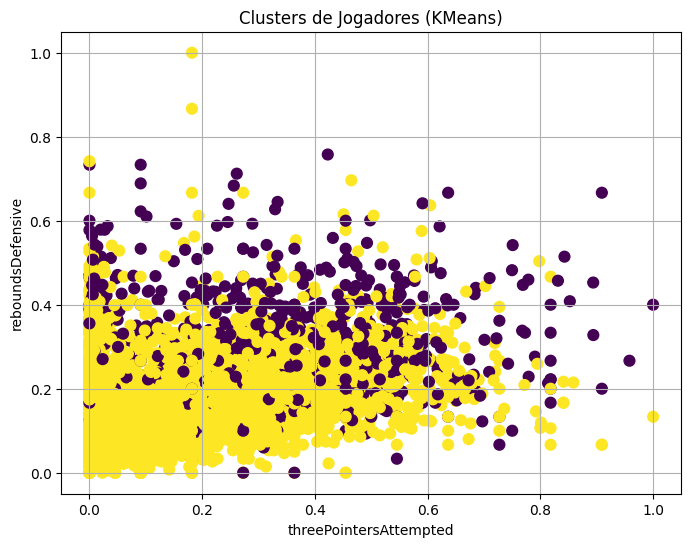

In [82]:
kmeans3 = KMeans(n_clusters=2, random_state=0, n_init="auto").fit_predict(df_f_no_wins)
df_f['cluster'] = kmeans3
plt.figure(figsize=(8, 6))
plt.scatter(df_f['threePointersAttempted'], df_f['reboundsDefensive'], c=df_f['cluster'], cmap='viridis', s=60)
plt.xlabel('threePointersAttempted')
plt.ylabel('reboundsDefensive')
plt.title('Clusters de Jogadores (KMeans)')
plt.grid(True)
plt.show()

In [98]:
group_f = df_f.groupby(by = 'cluster').mean().reset_index()
group_c = df_c.groupby(by = 'cluster').mean().reset_index()
group_g = df_g.groupby(by = 'cluster').mean().reset_index()


In [99]:
group_f

,cluster,threePointersAttempted,reboundsDefensive,steals,turnovers,minutes,W
0,0,0.349044,0.311077,0.256279,0.291214,0.735569,14.247511
1,1,0.194296,0.175568,0.140706,0.120185,0.446239,11.221488


In [107]:
group_c['cluster'] = group_c.apply(lambda x: 0 if x['cluster'] == 1 else 1, axis = 1)
group_c.sort_values(by = 'W', ascending = False)

,cluster,freeThrowsMade,reboundsDefensive,reboundsOffensive,blocks,minutes,W
1,0,0.222077,0.372004,0.306817,0.299299,0.620216,12.844025
0,1,0.069457,0.149914,0.136882,0.119800,0.292576,10.664547


In [101]:
group_g

,cluster,threePointersAttempted,assists,steals,turnovers,minutes,W
0,0,0.350155,0.325810,0.270598,0.285039,0.662715,12.357361
1,1,0.152402,0.112098,0.124713,0.107920,0.331799,9.331220


In [59]:
import statsmodels.api as sm

X = df['position']
exog = sm.add_constant(X)
poission_model = sm.GLM(df_c['W'], exog, family=sm.families.Poisson())
result = poission_model.fit()

result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                      W   No. Observations:                 2053
Model:                            GLM   Df Residuals:                     2046
Model Family:                 Poisson   Df Model:                            6
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -7093.5
Date:                Sun, 08 Jun 2025   Deviance:                       5691.8
Time:                        21:36:25   Pearson chi2:                 5.49e+03
No. Iterations:                     4   Pseudo R-squ. (CS):             0.2298
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 2.1285      0.020    108.334      0.000       2.090       2.167
freeThrowsMade       -0.0546      0.067     -0.820      0.412      -0.185       0.076
reboundsDefensive     0.0656      0.083      0.789      0.430      -0.097       0.228
reboundsOffensive    -0.2217      0.067     -3.292      0.001      -0.354      -0.090
blocks               -0.3554      0.053     -6.712      0.000      -0.459      -0.252
minutes               1.0209      0.069     14.725      0.000       0.885       1.157
cluster              -0.0544      0.024     -2.287      0.022      -0.101      -0.008
=====================================================================================
"""